# 09 – Pivot Analysis

Ce notebook charge les artefacts `probabilities` générés par un run MLflow (cf. `08_modeling_point_total.ipynb`) et visualise la calibration des probabilités over/under pour chaque pivot. Ajuste les chemins ci-dessous pour pointer vers le run/ modèle que tu veux analyser.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Répertoire du run MLflow à analyser
RUN_DIR = Path("mlruns/351026250497371967/4140b0f8695e440487c593eaa0c44691/")
MODEL_KEY = "stacking"  # 'lgbm', 'xgb', 'ngboost', 'stacking'

summary_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / f"{MODEL_KEY}_pivot_summary.csv"
samples_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / "samples" / f"{MODEL_KEY}_pivot_samples.csv"

summary_df = pd.read_csv(summary_path)
samples_df = pd.read_csv(samples_path)
samples_df["actual_over"] = (samples_df["actual"] > samples_df["pivot"]).astype(int)
samples_df["pred_over"] = samples_df["prob_over"]

display(summary_df.head())
display(samples_df.head())

,pivot,prob_under,prob_over
0,218.5,0.748297,0.251703
1,219.5,0.763824,0.236176
2,220.5,0.778828,0.221172
3,221.5,0.793292,0.206708
4,222.5,0.807203,0.192797


,prediction,actual,sigma,pivot,prob_under,prob_over,actual_over,pred_over
0,192.938399,200,15.686148,230.5,0.991680,0.008320,0,0.008320
1,223.526870,249,16.441340,235.5,0.766765,0.233235,1,0.233235
2,196.396862,178,14.179858,237.5,0.998126,0.001874,0,0.001874
3,207.945531,180,17.237429,235.5,0.945037,0.054963,0,0.054963
4,204.190267,211,16.592271,236.5,0.974249,0.025751,0,0.025751


## Calibration par pivot

,pivot,actual_over_rate,predicted_over,count
0,218.5,0.272727,0.213947,11
1,219.5,0.000000,0.137310,6
2,220.5,0.375000,0.374941,8
3,221.5,0.250000,0.170545,4
4,222.5,0.333333,0.156471,6
5,223.5,0.250000,0.147526,12
6,224.5,0.200000,0.210531,10
7,225.5,0.166667,0.223303,6
8,226.5,0.000000,0.164555,1
9,227.5,0.000000,0.097567,6


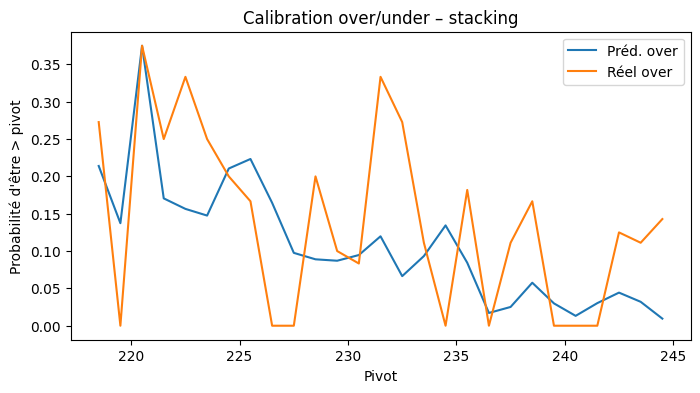

In [2]:
pivot_stats = (
    samples_df.groupby("pivot")
    .agg(
        actual_over_rate=("actual_over", "mean"),
        predicted_over=("pred_over", "mean"),
        count=("actual_over", "size"),
    )
    .reset_index()
)

display(pivot_stats)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pivot_stats["pivot"], pivot_stats["predicted_over"], label="Préd. over")
ax.plot(pivot_stats["pivot"], pivot_stats["actual_over_rate"], label="Réel over")
ax.set_xlabel("Pivot")
ax.set_ylabel("Probabilité d'être > pivot")
ax.legend()
ax.set_title(f"Calibration over/under – {MODEL_KEY}")
plt.show()

## Classement des pivots les plus "sûrs"

On calcule ci-dessous un score simple : distance entre la probabilité de dépassement et 0.5 (plus la probabilité est éloignée de 50 %, plus le modèle est confiant), pondéré par la différence entre la prédiction et la réalité.

In [3]:
samples_df["confidence"] = (samples_df["prob_over"] - 0.5).abs()
samples_df["hit"] = (samples_df["prob_over"] > 0.5) == (samples_df["actual"] > samples_df["pivot"])

top_edges = (
    samples_df.sort_values("confidence", ascending=False)
    [["prediction", "actual", "pivot", "prob_over", "prob_under", "confidence", "hit"]]
    .head(20)
)
display(top_edges)

,prediction,actual,pivot,prob_over,prob_under,confidence,hit
9,186.840309,210,235.5,0.000001,0.999999,0.499999,True
150,185.429811,221,237.5,0.000008,0.999992,0.499992,True
51,189.452988,169,242.5,0.000044,0.999956,0.499956,True
39,188.887151,186,244.5,0.000044,0.999956,0.499956,True
110,186.145506,174,239.5,0.000095,0.999905,0.499905,True
155,188.815040,175,232.5,0.000118,0.999882,0.499882,True
181,194.729768,137,240.5,0.000120,0.999880,0.499880,True
91,189.753461,182,241.5,0.000131,0.999869,0.499869,True
8,193.701806,205,243.5,0.000147,0.999853,0.499853,True
199,201.756234,239,244.5,0.000183,0.999817,0.499817,True


## Pivot bins (2 pts)

/tmp/ipykernel_29603/2097160386.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby('pivot_bin')


,pivot_bin,count,actual_over_rate,predicted_over
0,"[218.5, 220.5)",17,0.176471,0.186899
1,"[220.5, 222.5)",12,0.333333,0.306809
2,"[222.5, 224.5)",18,0.277778,0.150508
3,"[224.5, 226.5)",16,0.187500,0.215321
4,"[226.5, 228.5)",7,0.000000,0.107136
5,"[228.5, 230.5)",15,0.133333,0.087673
6,"[230.5, 232.5)",15,0.133333,0.099676
7,"[232.5, 234.5)",20,0.200000,0.078507
8,"[234.5, 236.5)",14,0.142857,0.095067
9,"[236.5, 238.5)",16,0.062500,0.021621


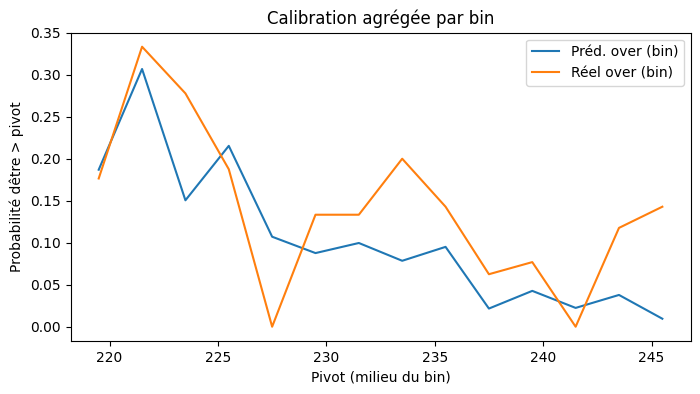

In [5]:
bin_edges = pd.interval_range(start=218.5, end=246.5, freq=2, closed='left')
samples_df['pivot_bin'] = pd.cut(samples_df['pivot'], bins=bin_edges)
bin_stats = (
    samples_df.groupby('pivot_bin')
    .agg(count=('actual_over','size'), actual_over_rate=('actual_over','mean'), predicted_over=('prob_over','mean'))
    .reset_index()
)
display(bin_stats)
if not bin_stats.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    mids = bin_stats['pivot_bin'].apply(lambda x: x.mid if pd.notna(x) else pd.NA)
    ax.plot(mids, bin_stats['predicted_over'], label='Préd. over (bin)')
    ax.plot(mids, bin_stats['actual_over_rate'], label='Réel over (bin)')
    ax.set_xlabel('Pivot (milieu du bin)')
    ax.set_ylabel('Probabilité dêtre > pivot')
    ax.legend()
    ax.set_title('Calibration agrégée par bin')
    plt.show()


## Confiance vs taux de réussite

In [ ]:
confidence_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]
records = []
for thresh in confidence_thresholds:
    subset = samples_df[samples_df['confidence'] >= thresh]
    hit_rate = subset['hit'].mean() if not subset.empty else float('nan')
    records.append({'threshold': thresh, 'count': len(subset), 'hit_rate': hit_rate})
confidence_df = pd.DataFrame(records)
display(confidence_df)


,threshold,count,hit_rate
0,0.05,199,0.859296
1,0.10,191,0.874346
2,0.15,181,0.889503
3,0.20,174,0.890805
4,0.25,168,0.892857


## Distribution des sigma

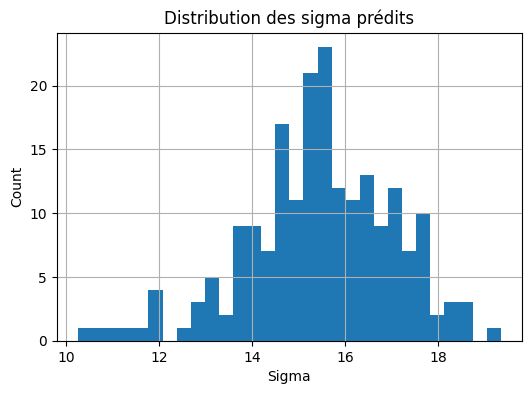

In [ ]:
if 'sigma' in samples_df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    samples_df['sigma'].hist(bins=30, ax=ax)
    ax.set_title('Distribution des sigma prédits')
    ax.set_xlabel('Sigma')
    ax.set_ylabel('Count')
    plt.show()
else:
    print('Colonne sigma absente du fichier samples.')
